In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
import backtest.run

mid, sigma, events = backtest.run.load_artifacts()

In [4]:
train_results = backtest.run.run(mid, sigma, events)

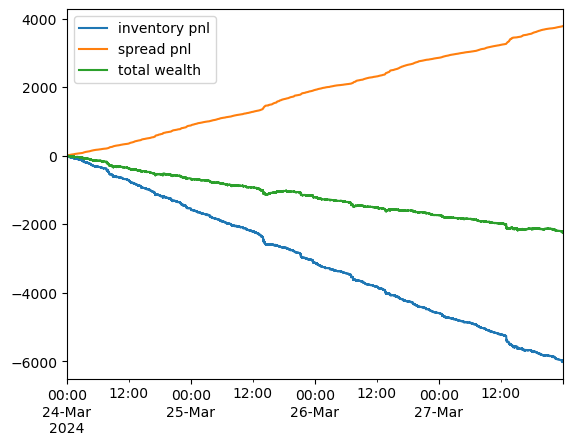

In [5]:
import matplotlib.pyplot as plt

inv_pnl = (train_results['q'].shift() * train_results['mid'].diff()).cumsum() # compute inventory riding market movement
spread_pnl = (train_results['wealth'] - train_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

inv_pnl.plot(label = 'inventory pnl')
spread_pnl.plot(label = 'spread pnl')
train_results['wealth'].plot(label = 'total wealth')
plt.legend()
plt.show()

In [6]:
# average half-spread

half_spread = (train_results['ask_quote'] - train_results['bid_quote']).mean() / 2

In [7]:
import backtest.symmetric_strategy

symmetric_results = backtest.run.run(mid, sigma, events, 
                                     strategy_cls = backtest.symmetric_strategy.SymmetricStrategy,
                                     strategy_kwargs = {'half_spread': half_spread})

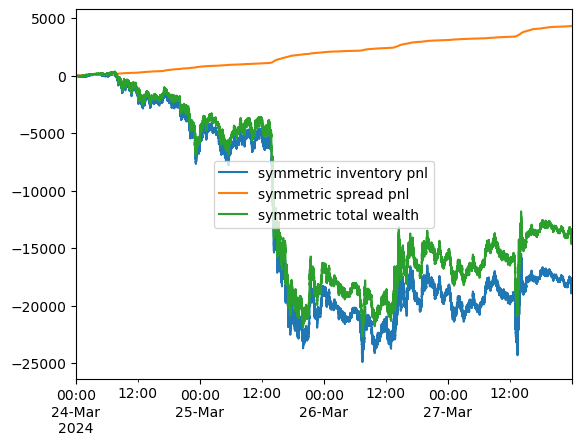

In [10]:
sym_inv_pnl = (symmetric_results['q'].shift() * symmetric_results['mid'].diff()).cumsum() # compute inventory riding market movement
sym_spread_pnl = (symmetric_results['wealth'] - symmetric_results['wealth'].dropna().iloc[0]) - sym_inv_pnl # cash flow

sym_inv_pnl.plot(label = 'symmetric inventory pnl')
sym_spread_pnl.plot(label = 'symmetric spread pnl')
symmetric_results['wealth'].plot(label = 'symmetric total wealth')
plt.legend()
plt.show()

In [11]:
from config import BINANCE_PATH

train_results.to_parquet(BINANCE_PATH / 'as_results.parquet')
symmetric_results.to_parquet(BINANCE_PATH / 'symmetric_results.parquet')